# Naive Bayes TF IDF— MBTI Binary Dimensions
This notebook trains four binary Multinomial Naive Bayes classifiers (one per MBTI dimension).

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import f1_score



--- STEP 1: Load the CSV ---

In [16]:
print(" Loading data from CSV...")

# Find the file
current_dir = Path.cwd()
csv_path = None

# Search 'preprocessed_data.csv' in current and parent folders
for parent in [current_dir] + list(current_dir.parents)[:3]:
    candidate = parent / 'data' / 'processed' / 'preprocessed_data.csv'
    if candidate.exists():
        csv_path = candidate
        break

# Check if csv_path was found
if csv_path is None:
    raise FileNotFoundError(f" Could not find 'preprocessed_data.csv' in current directory or parent folders")

print(f" Found CSV at: {csv_path}")

 Loading data from CSV...
 Found CSV at: c:\Users\Stijn\OneDrive - KU Leuven\UNIF\MASTER1\MACHINE LEARNING\ML_MBTI_project\data\processed\preprocessed_data.csv


--- Read the CSV and TF_IDF vectorization ---


In [17]:
df = pd.read_csv(csv_path)
print(f"   Columns found: {df.columns.tolist()}")
text_col = 'posts' 
target_col = 'type'

# Remove rows where text or type is missing
df = df.dropna(subset=[text_col, target_col]) 

# Do NOT vectorize here yet
print("\n Preparing raw text for pipeline...")
X = df[text_col].values  
y = df[target_col].values

print(f"Data shape: {X.shape[0]} rows")

   Columns found: ['type', 'posts', 'num_posts', 'no. of. words', 'type_encoded']

 Preparing raw text for pipeline...
Data shape: 8462 rows


--- STEP 3: Train with GridSearchCV & Cross-Validation ---


 Starting Naive Bayes with Pipeline (TF-IDF + Tuning)

--- Tuning I vs E ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best F1-Score: 0.6098
Best Params: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'tfidf__max_features': 5000}
 Training F1: 0.7730
 Test F1:     0.6098
 Overfitting Gap: 16.32% (HIGH)
   Confusion Matrix (Full Data):
[[5377 1157]
 [ 480 1448]]

--- Tuning N vs S ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best F1-Score: 0.6055
Best Params: {'classifier__alpha': 0.1, 'classifier__fit_prior': True, 'tfidf__max_features': 5000}
 Training F1: 0.7760
 Test F1:     0.6055
 Overfitting Gap: 17.05% (HIGH)
   Confusion Matrix (Full Data):
[[6320  964]
 [ 268  910]]

--- Tuning T vs F ---
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best F1-Score: 0.7357
Best Params: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'tfidf__max_features': 5000}
 Training F1: 0.8192
 Test F1:     0.7357
 Overfitting Gap: 

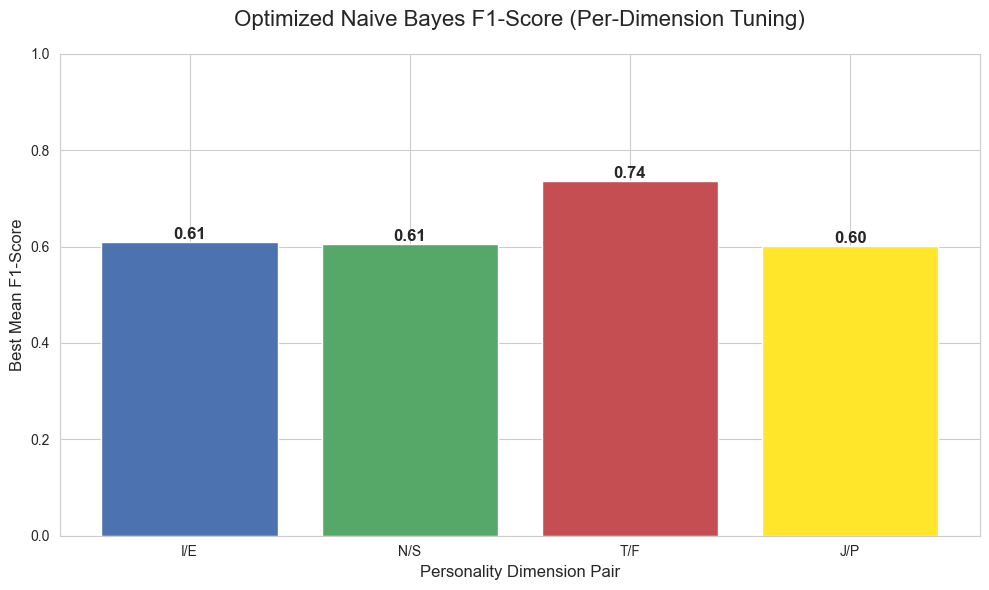


 Optimization Summary:
  I/E: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'tfidf__max_features': 5000}
  N/S: {'classifier__alpha': 0.1, 'classifier__fit_prior': True, 'tfidf__max_features': 5000}
  T/F: {'classifier__alpha': 0.01, 'classifier__fit_prior': True, 'tfidf__max_features': 5000}
  J/P: {'classifier__alpha': 5.0, 'classifier__fit_prior': True, 'tfidf__max_features': 5000}

 Average Optimized F1-Score: 0.6380


In [18]:
print("\n Starting Naive Bayes with Pipeline (TF-IDF + Tuning)")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results = {}
best_params_log = {}
best_gap_log = {}

# Set up 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the Pipeline with Vectorizer included
pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')), 
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', MultinomialNB())
])

param_grid = {
    'tfidf__max_features': [5000],          # Tune vocabulary size
    'classifier__alpha': [0.01, 0.1, 1.0, 5.0],     # Regularization
    'classifier__fit_prior': [True, False]
}

sns.set_style("whitegrid")

for trait1, trait2 in dimensions:
    print(f"\n--- Tuning {trait1} vs {trait2} ---")
    
    # Create binary labels (unchanged)
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # return_train_score=True to check for overfitting
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        return_train_score=True # N
    )
    
    # The pipeline handles the conversion internally for every fold
    grid_search.fit(X, y_binary)
    
    # Store results
    best_score = grid_search.best_score_
    best_params = grid_search.best_params_
    results[f"{trait1}/{trait2}"] = best_score
    best_params_log[f"{trait1}/{trait2}"] = best_params
    
    # Calculate and Print Overfitting Gap ---
    best_index = grid_search.best_index_
    train_score = grid_search.cv_results_['mean_train_score'][best_index]
    test_score = grid_search.cv_results_['mean_test_score'][best_index]
    gap = train_score - test_score
    best_gap_log[f"{trait1}/{trait2}"] = gap

    # Print Summary
    print(f"Best F1-Score: {best_score:.4f}")
    print(f"Best Params: {best_params}")
    print(f" Training F1: {train_score:.4f}")
    print(f" Test F1:     {test_score:.4f}")
    print(f" Overfitting Gap: {gap:.2%} ({'HIGH' if gap > 0.10 else 'OK'})")
    # ---------------------------------------------------------
    
    # Confusion Matrix
    y_pred_full = grid_search.predict(X)
    print(f"   Confusion Matrix (Full Data):\n{confusion_matrix(y_binary, y_pred_full)}")

#PLOTTING 
print("\n Generating Bar Graph of Best Scores...")
plt.figure(figsize=(10, 6))
keys = list(results.keys())
values = list(results.values())
bars = plt.bar(keys, values, color=['#4c72b0', '#55a868', '#c44e52', "#ffe62a"])
plt.title('Optimized Naive Bayes F1-Score (Per-Dimension Tuning)', fontsize=16, pad=20)
plt.xlabel('Personality Dimension Pair', fontsize=12)
plt.ylabel('Best Mean F1-Score', fontsize=12)
plt.ylim(0, 1.0)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

#SUMMARY
print("\n Optimization Summary:")
for dim, params in best_params_log.items():
    print(f"  {dim}: {params}")

avg_f1 = sum(results.values()) / len(results)
print(f"\n Average Optimized F1-Score: {avg_f1:.4f}")

In [19]:
# --- Final Summary ---
print("\n" + "="*30)
print("FINAL RESULTS")
print("="*30)
for pair, score in results.items():
    print(f"{pair}: {score:.2%}")


FINAL RESULTS
I/E: 60.98%
N/S: 60.55%
T/F: 73.57%
J/P: 60.11%


In [20]:
print("\n Starting Naive Bayes - Optimizing for STABILITY (Low Overfitting)...")

dimensions = [('I', 'E'), ('N', 'S'), ('T', 'F'), ('J', 'P')]
results_stable = {}
best_params_stable = {}
best_stable_gap_dict = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')), 
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', MultinomialNB())
])

# test high Alpha values here to force stability
param_grid = {
    'tfidf__max_features': [5000],
    'classifier__alpha': [0.1, 1.0, 5.0, 10.0, 20.0],
    'classifier__fit_prior': [True, False]
}

for trait1, trait2 in dimensions:
    print(f"\n--- Tuning {trait1} vs {trait2} for Stability ---")
    
    y_binary = np.array([1 if trait2 in label else 0 for label in y])
    
    # 1. Run Grid Search but keep the Train Scores!
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1,
        return_train_score=True)  #to check overfitting
    
    grid_search.fit(X, y_binary)
    
    # 2. Extract Results
    cv_results = grid_search.cv_results_
    mean_test_scores = cv_results['mean_test_score']
    mean_train_scores = cv_results['mean_train_score']
    params = cv_results['params']

    #  Find the Most Stable set 

    
    best_stable_gap = float('inf')
    best_stable_params = None
    best_stable_score = 0
    
    # Only consider models that are at least 90% as good as the absolute best F1

    max_f1 = np.max(mean_test_scores)
    threshold = max_f1 * 0.90 
    
    for i in range(len(params)):
        test_score = mean_test_scores[i]
        
        if test_score > threshold: # Only check "good" models
            train_score = mean_train_scores[i]
            gap = train_score - test_score 
            
            if gap < best_stable_gap:
                best_stable_gap = gap
                best_stable_params = params[i]
                best_stable_score = test_score

    # Save Results
    results_stable[f"{trait1}/{trait2}"] = best_stable_score
    best_params_stable[f"{trait1}/{trait2}"] = best_stable_params
    best_stable_gap_dict[f"{trait1}/{trait2}"] = best_stable_gap
    
    print(f"   Selected Alpha for Stability: {best_stable_params['classifier__alpha']}")
    print(f"   Test Score: {best_stable_score:.4f}")
    print(f"   Overfitting Gap: {best_stable_gap:.4f} ({(best_stable_gap*100):.2f}%)")

# --- SUMMARY ---
print("\n Optimization Complete.")
print("Use these parameters to recreate Graph 5 (Low Overfitting):")
for dim, params in best_params_stable.items():
    print(f"  {dim}: {params}")


 Starting Naive Bayes - Optimizing for STABILITY (Low Overfitting)...

--- Tuning I vs E for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 20.0
   Test Score: 0.5985
   Overfitting Gap: 0.0903 (9.03%)

--- Tuning N vs S for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 5.0
   Test Score: 0.5506
   Overfitting Gap: 0.0991 (9.91%)

--- Tuning T vs F for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 20.0
   Test Score: 0.7139
   Overfitting Gap: 0.0480 (4.80%)

--- Tuning J vs P for Stability ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Selected Alpha for Stability: 20.0
   Test Score: 0.5992
   Overfitting Gap: 0.1015 (10.15%)

 Optimization Complete.
Use these parameters to recreate Graph 5 (Low Overfitting):
  I/E: {'classifier__alpha': 20.0, 'classifier__fit_prior': True, 'tfidf

In [21]:
import joblib

# Prepare model data in compatible format for comparison notebook
model_data = {
    'dimensions': list(results_stable.keys()),
    
    # Comprehensive metrics from stability optimization
    'metrics': {dim: {
        'f1_score': results_stable[dim]*100,
        'overfit_gap': best_gap_log[dim]*100,
    } for dim in results_stable},
    
    # Stability optimization results
    'best_params': {dim: best_params_stable[dim] for dim in best_params_stable},
    'gridsearch_stable_f1': {dim: results_stable[dim] for dim in results_stable},
    'gridsearch_stable_gaps': {dim: best_gap_log[dim] for dim in best_gap_log},
    'gridsearch_stable_params': {dim: best_params_stable[dim] for dim in best_params_stable},
    
    'optimization_type': 'stability',
    'model_type': 'Naive Bayes (BOW)',
    'hyperparameters': {
        'vectorizer': 'CountVectorizer',
        'max_features': 5000,
        'stop_words': 'english',
        'upsampling': True,
        'optimization': 'Stability (Low Overfitting)',
        'selection_criteria': 'Minimum overfitting gap among models within 90% of best F1'
    }
}

# Save
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)
save_path = models_dir / 'naive_bayes_IDF_stability_ng.pkl'
joblib.dump(model_data, save_path)
    
print(f"\n✓ Model data saved to: {save_path}")
print(f"  Contains {len(model_data['dimensions'])} dimension classifiers")
print(f"  Average F1: {np.mean(list(results_stable.values())):.4f}")
print(f"  Average Overfitting Gap: {np.mean(list(best_stable_gap_dict.values())):.2%}")


✓ Model data saved to: ..\models\naive_bayes_IDF_stability_ng.pkl
  Contains 4 dimension classifiers
  Average F1: 0.6156
  Average Overfitting Gap: 8.47%
